# Stage A — Same-state sibling-pair preferences for FDPO

End-to-end pipeline for generating preference pairs by RAP-sampling K candidate horizon continuations from each demo context, scoring with robometer, and emitting `(top, bottom)` as `(ξ⁺, ξ⁻)`. Drop-in to `scripts/train_align_fdpo.py` via the existing `PreferencePairDataset` shard schema.

**Run order (Day 1 plan):**
1. Setup cell (imports, robometer client).
2. Sampler + models/dataset cells.
3. **Day-0 audit** — GO/NO-GO on robometer calibration.
4. Single-window POC — check K-arm spread per window.
5. Generate shards on N windows (50 for smoke, full dataset after train cycle confirms signal).
6. Train via `scripts/train_align_fdpo.py` (command in last md cell).

In [6]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import h5py
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mediapy
import numpy as np
import torch
from omegaconf import OmegaConf
from tqdm import tqdm

from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.models.utils import load_denoiser, load_tokenizer

# Robometer client.
sys.path.append("/home/mim-server/projects/robometer/scripts")
from robometer_reward import RobometerReward
rm = RobometerReward("http://localhost:8000")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

# Stage A — Same-state sibling-pair preferences (pushT)

Construct preference pairs by **RAP-sampling K candidate horizon continuations from the same demo context**, scoring each with robometer, and emitting `(top-progress, bottom-progress)` as `(ξ⁺, ξ⁻)`.

Pos and neg now come from the **same generative distribution**, eliminating the v0/v0a source-confound (demo-vs-rollout) that drove DPO saturation. The contrast is over task progress only.

Drop-in compatible with `scripts/train_align_fdpo.py` — same `PreferencePairDataset` shard schema as `gen_fdpo_negatives.py`.

**Run order:** Day-0 audit cell first (verify robometer signal on pushT) → POC cell (single-window sanity check) → scale cell (generate shards) → existing FDPO trainer (no code change).

In [7]:
# Progressive rolling sampler — inlined from scripts/preprocessing/gen_fdpo_negatives.py
# to keep this notebook self-contained.
import torch
from dreamerv4uwm.sampling import get_noise_index

@torch.no_grad()
def progressive_rolling_sampler(
    denoiser, init_latents, init_actions, total_pred_steps,
    window_size=16, context_size=8, context_cond_tau=0.9, action_noise_std=1.0,
):
    F, C = window_size, context_size
    device, dtype = init_latents.device, init_latents.dtype
    B, T_init, N_lat, D_lat = init_latents.shape
    n_act = init_actions.shape[-1]
    init_actions = init_actions.to(device=device, dtype=dtype)
    assert C <= T_init
    N = denoiser.cfg.denoiser.num_noise_levels
    assert N % F == 0
    stride = N // F
    step_size = 1.0 / F
    tau_cond_idx = get_noise_index(context_cond_tau, N)

    prefix_obs = init_latents[:, -C:].clone() if C > 0 else None
    prefix_act = init_actions[:, -C:].clone() if C > 0 else None
    z_obs = torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype)
    z_act = action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype)
    tau_idx = torch.zeros((B, 1), dtype=torch.long, device=device)

    def _fresh_noise():
        return (
            torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype),
            action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype),
            torch.zeros((B, 1), dtype=torch.long, device=device),
        )

    pred_obs_buf, pred_act_buf = [], []
    while len(pred_obs_buf) < total_pred_steps:
        cur_F = z_obs.shape[1]
        if C > 0:
            p_obs_in = (1.0 - context_cond_tau) * torch.randn_like(prefix_obs) + context_cond_tau * prefix_obs
            p_act_in = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(prefix_act)
                        + context_cond_tau * prefix_act)
            obs_in = torch.cat([p_obs_in, z_obs], dim=1)
            act_in = torch.cat([p_act_in, z_act], dim=1)
            prefix_sigma = torch.full((B, C), tau_cond_idx, dtype=torch.long, device=device)
            sigma_idx = torch.cat([prefix_sigma, tau_idx], dim=1)
        else:
            obs_in, act_in, sigma_idx = z_obs, z_act, tau_idx
        step_idx_tensor = torch.zeros((B, C + cur_F), dtype=torch.long, device=device)
        out = denoiser(
            noisy_act=act_in, noisy_obs=obs_in,
            obs_sigma_idx=sigma_idx, obs_step_idx=step_idx_tensor,
            act_sigma_idx=sigma_idx, act_step_idx=step_idx_tensor,
        )
        if isinstance(out, tuple) and len(out) == 3:
            z_hat, act_hat, _ = out
        else:
            z_hat, act_hat = out
        act_hat = act_hat.squeeze(-2)
        z_hat_w, act_hat_w = z_hat[:, C:], act_hat[:, C:]
        tau_cont = tau_idx.float() / float(N)
        denom = (1.0 - tau_cont).clamp_min(1e-5)
        z_obs = z_obs + (z_hat_w - z_obs) / denom[..., None, None] * step_size
        z_act = z_act + (act_hat_w - z_act) / denom[..., None] * step_size
        tau_idx = tau_idx + stride
        if cur_F < F:
            new_o, new_a, new_t = _fresh_noise()
            z_obs = torch.cat([z_obs, new_o], dim=1)
            z_act = torch.cat([z_act, new_a], dim=1)
            tau_idx = torch.cat([tau_idx, new_t], dim=1)
        else:
            emit_obs, emit_act = z_obs[:, :1], z_act[:, :1]
            pred_obs_buf.append(emit_obs)
            pred_act_buf.append(emit_act)
            new_o, new_a, new_t = _fresh_noise()
            z_obs = torch.cat([z_obs[:, 1:], new_o], dim=1)
            z_act = torch.cat([z_act[:, 1:], new_a], dim=1)
            tau_idx = torch.cat([tau_idx[:, 1:], new_t], dim=1)
            if C > 0:
                prefix_obs = torch.cat([prefix_obs[:, 1:], emit_obs], dim=1)
                prefix_act = torch.cat([prefix_act[:, 1:], emit_act], dim=1)
    return torch.cat(pred_obs_buf, dim=1), torch.cat(pred_act_buf, dim=1)

In [8]:
# Models + dataset + knobs for Stage A — pushT.

# --- paths ---
DEMO_DATA_DIR  = "/home/mim-server/datasets/pushT/sharded-demo"
CKPT_DIR       = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/final/joint-model/v1"
CKPT_FILE      = "432360.pt"
TOKENIZER_CKPT = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer_ckpts/pushT.pt"

# --- knobs (shard schema matches v1 / train_align_fdpo.py expectations) ---
CTX_FRAMES   = 1
HORIZON      = 16
K_ARMS       = 8
WINDOW_SIZE  = 4        # F: progressive sampler depth
TASK_PROMPT  = "push the T-shaped block to the goal at the center of the board"
DEVICE       = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
SEED         = 0

# --- load models ---
cfg = OmegaConf.load(Path(CKPT_DIR) / 'config.yaml')
cfg.dynamics_ckpt  = str(Path(CKPT_DIR) / CKPT_FILE)
cfg.tokenizer_ckpt = TOKENIZER_CKPT
if 'latent_attends_action' in cfg.denoiser:
    del cfg.denoiser['latent_attends_action']

max_seq = CTX_FRAMES + HORIZON
denoiser  = load_denoiser(cfg,  DEVICE, max_num_forward_steps=max_seq).eval()
tokenizer = load_tokenizer(cfg, DEVICE, max_num_forward_steps=max_seq).eval()
for p in denoiser.parameters():  p.requires_grad_(False)
for p in tokenizer.parameters(): p.requires_grad_(False)
N_ACT = cfg.denoiser.n_actions
print(f"  denoiser n_actions={N_ACT}  ctx={CTX_FRAMES}  horizon={HORIZON}  K={K_ARMS}")

# --- demo dataset (windows of length ctx+horizon) ---
demo_ds = ShardedHDF5Dataset(
    data_dir=DEMO_DATA_DIR, window_size=CTX_FRAMES+HORIZON, stride=8,
    split='train', train_fraction=1.0, split_seed=123, shuffle_windows=False,
)
print(f"  demo windows: {len(demo_ds)} (stride=8, window={CTX_FRAMES+HORIZON})")

  denoiser n_actions=2  ctx=1  horizon=16  K=8
Train split: 1098 windows from 78 episodes
  demo windows: 1098 (stride=8, window=17)


## Day-0 audit — robometer signal on pushT demo windows

**Goal:** verify robometer produces a meaningful, ordered task-progress signal on **demo windows** (17-frame slices), not full episodes. A window may slice into the early, middle, or late portion of an episode, so we cannot expect terminal progress to be near 1.0.

What we *can* expect from a reliable reward model:

1. **Within-window monotonicity.** Demos always advance the task, so for most windows `progress[-1] > progress[0]`. Target: fraction with `delta > 0` is `> 0.70`.
2. **Delta magnitude.** The within-window increment must be meaningfully above noise — otherwise robometer can't discriminate K=8 sibling rollouts at the same episode position. Target: mean `|delta|` `> 0.05`.
3. **Spread across episode positions.** Sampling windows from varied points in episodes should produce terminal-progress values spanning a meaningful range — early-episode windows should score low, late-episode high. Target: `spread of terminal progress > 0.30`.

All three must pass. **GO/NO-GO** — if any fails, robometer is not reliable enough on pushT to partition K=8 rollouts, and Stage A pairs will be trained on noise.

audit_imgs: (16, 17, 3, 256, 256)   progress: (16, 17)

=== Day-0 audit (16 demo windows) ===
  fraction with delta > 0:        1.00   (want > 0.70)
  mean |delta| (within-window):   0.520   (want > 0.05)
  spread of terminal progress:    0.409   (want > 0.30)
  cond 1 (monotonicity):  PASS
  cond 2 (delta mag):     PASS
  cond 3 (spread):        PASS

=> PASS — robometer has usable signal for Stage A


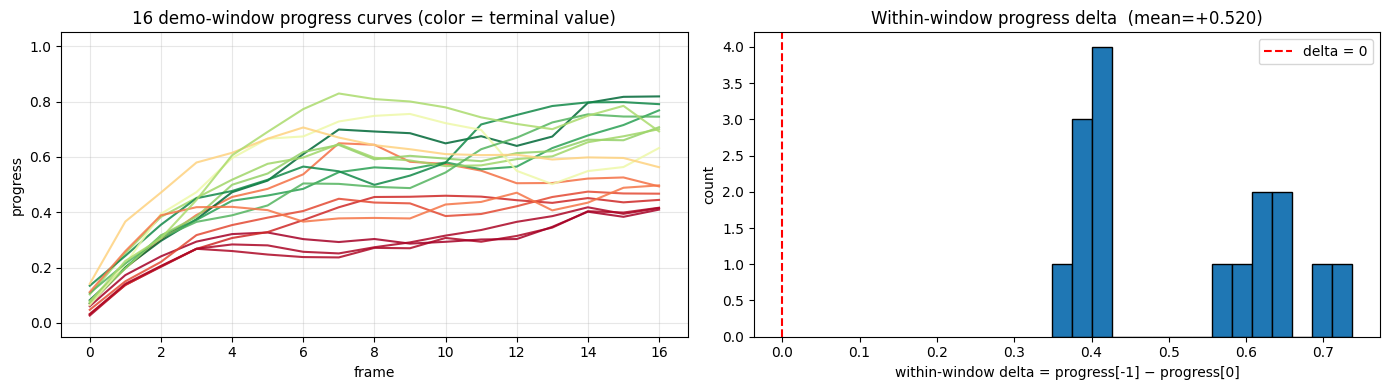

In [9]:
# Make sure rm is alive in this kernel (re-import after restarts).
import sys
sys.path.append("/home/mim-server/projects/robometer/scripts")
from robometer_reward import RobometerReward
rm = RobometerReward("http://localhost:8000")

# Sample more windows to capture varied episode positions.
N_AUDIT = 16
audit_indices = np.linspace(0, len(demo_ds) - 1, N_AUDIT, dtype=int)
audit_imgs = torch.stack([
    demo_ds[int(i)]['image'].clamp(0, 1).float()[:CTX_FRAMES + HORIZON]
    for i in audit_indices
], dim=0)  # (N, T, 3, H, W)

out_audit = rm.predict(audit_imgs, [TASK_PROMPT] * N_AUDIT)
prog = out_audit.progress.cpu().numpy()   # (N, T')
print(f"audit_imgs: {tuple(audit_imgs.shape)}   progress: {tuple(prog.shape)}")

# Metrics on the WINDOW level, not episode level.
start = prog[:, 0]
end   = prog[:, -1]
delta = end - start

frac_progressing = float((delta > 0).mean())
mean_abs_delta   = float(np.abs(delta).mean())
spread_terminal  = float(end.max() - end.min())

print(f"\n=== Day-0 audit ({N_AUDIT} demo windows) ===")
print(f"  fraction with delta > 0:        {frac_progressing:.2f}   (want > 0.70)")
print(f"  mean |delta| (within-window):   {mean_abs_delta:.3f}   (want > 0.05)")
print(f"  spread of terminal progress:    {spread_terminal:.3f}   (want > 0.30)")

c1 = frac_progressing > 0.70
c2 = mean_abs_delta   > 0.05
c3 = spread_terminal  > 0.30
print(f"  cond 1 (monotonicity):  {'PASS' if c1 else 'FAIL'}")
print(f"  cond 2 (delta mag):     {'PASS' if c2 else 'FAIL'}")
print(f"  cond 3 (spread):        {'PASS' if c3 else 'FAIL'}")
print(f"\n=> {'PASS — robometer has usable signal for Stage A' if (c1 and c2 and c3) else 'FAIL — robometer signal too weak; reconsider before generating pairs'}")

# Plot: progress curves overlaid, colored by terminal value (red→green).
import matplotlib.cm as cm
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
norm_t = (end - end.min()) / max(end.max() - end.min(), 1e-6)
for i in range(N_AUDIT):
    axes[0].plot(prog[i], lw=1.5, alpha=0.85, color=cm.RdYlGn(float(norm_t[i])))
axes[0].set_xlabel('frame'); axes[0].set_ylabel('progress')
axes[0].set_ylim(-0.05, 1.05); axes[0].grid(alpha=0.3)
axes[0].set_title(f'{N_AUDIT} demo-window progress curves (color = terminal value)')

axes[1].hist(delta, bins=15, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', label='delta = 0')
axes[1].set_xlabel('within-window delta = progress[-1] − progress[0]')
axes[1].set_ylabel('count')
axes[1].set_title(f'Within-window progress delta  (mean={delta.mean():+.3f})')
axes[1].legend()
plt.tight_layout(); plt.show()

In [10]:
import mediapy
imgs = audit_imgs.permute(0, 1, 3, 4, 2)  # (4, T, H, W, 3) for mediapy
mediapy.show_videos(
    {f"demo[{int(idx), int(i)}]": imgs[i].cpu().numpy() for i, idx in enumerate(audit_indices)},
    fps=5,
)

"demo[(0, 0)] This browser does not support the video tag.","demo[(73, 1)] This browser does not support the video tag.","demo[(146, 2)] This browser does not support the video tag.","demo[(219, 3)] This browser does not support the video tag.","demo[(292, 4)] This browser does not support the video tag.","demo[(365, 5)] This browser does not support the video tag.","demo[(438, 6)] This browser does not support the video tag.","demo[(511, 7)] This browser does not support the video tag.","demo[(585, 8)] This browser does not support the video tag.","demo[(658, 9)] This browser does not support the video tag.","demo[(731, 10)] This browser does not support the video tag.","demo[(804, 11)] This browser does not support the video tag.","demo[(877, 12)] This browser does not support the video tag.","demo[(950, 13)] This browser does not support the video tag.","demo[(1023, 14)] This browser does not support the video tag.","demo[(1097, 15)] This browser does not support the video tag."


## Single-window proof-of-concept

For one demo window, sample K=8 horizon continuations in parallel from the play-trained denoiser. Score each with robometer; identify top vs bottom arm. The spread between best and worst arm tells you the per-window signal strength — if median spread across many windows is small, raise K or switch to RAP-mode (lower `context_cond_tau`) for more diversity.

window 274: final progress per arm = [0.411 0.666 0.447 0.393 0.574 0.467 0.44  0.618]
top arm 1: 0.666   bot arm 3: 0.393   spread: 0.273


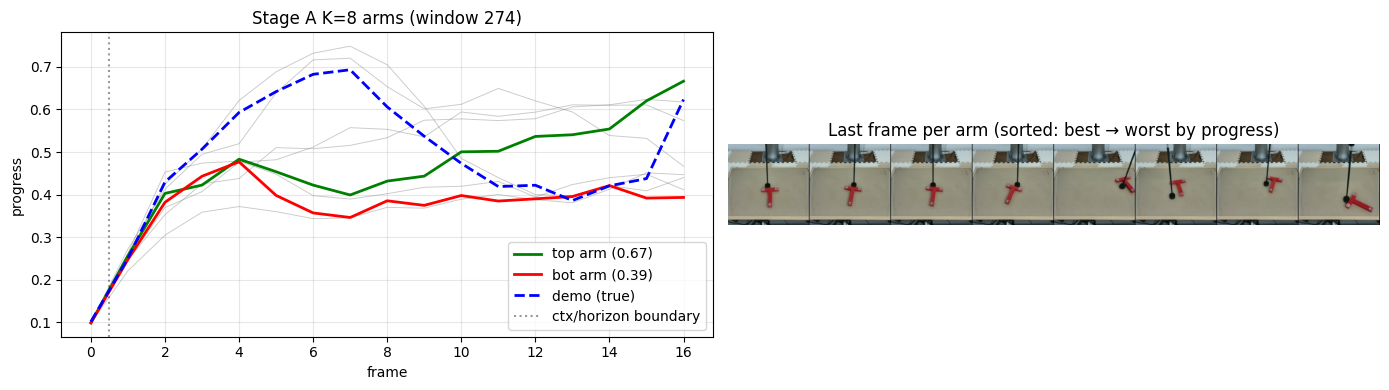

In [11]:
torch.manual_seed(SEED)
np.random.seed(SEED)

# Pick one demo window (somewhere in the middle of an episode).
demo_idx = len(demo_ds) // 4
sample = demo_ds[demo_idx]
demo_imgs = sample['image'].clamp(0,1).float()[:CTX_FRAMES+HORIZON].to(DEVICE)   # (T, 3, H, W)
demo_acts = sample['action'][:CTX_FRAMES+HORIZON, :N_ACT].float().to(DEVICE)

# K parallel rollouts: B=K with replicated context. progressive_rolling_sampler
# samples fresh noise per batch element, so the K outputs are independent.
with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    ctx_latents = tokenizer.encode(demo_imgs[:CTX_FRAMES].unsqueeze(0))               # (1, ctx, N, D)
    ctx_latents = ctx_latents.expand(K_ARMS, -1, -1, -1).contiguous()
    ctx_actions = demo_acts[:CTX_FRAMES].unsqueeze(0).expand(K_ARMS, -1, -1).contiguous()
    pred_latents, pred_actions = progressive_rolling_sampler(
        denoiser, init_latents=ctx_latents, init_actions=ctx_actions,
        total_pred_steps=HORIZON, window_size=WINDOW_SIZE, context_size=CTX_FRAMES,
    )
    pred_imgs = tokenizer.decode(pred_latents).clamp(0, 1)                            # (K, horizon, 3, H, W)

# Stitch (context + horizon) and score with robometer.
ctx_imgs_K = demo_imgs[:CTX_FRAMES].unsqueeze(0).expand(K_ARMS, -1, -1, -1, -1).cpu()
arms_full  = torch.cat([ctx_imgs_K, pred_imgs.cpu()], dim=1).float()                  # (K, T, 3, H, W)
out_K = rm.predict(arms_full, [TASK_PROMPT] * K_ARMS)
out_demo = rm.predict(demo_imgs[None].cpu().float(), [TASK_PROMPT])

final_K = out_K.progress[:, -1].cpu().numpy()
top_i, bot_i = int(np.argmax(final_K)), int(np.argmin(final_K))
print(f"window {demo_idx}: final progress per arm = {np.round(final_K, 3)}")
print(f"top arm {top_i}: {final_K[top_i]:.3f}   bot arm {bot_i}: {final_K[bot_i]:.3f}   "
      f"spread: {final_K[top_i] - final_K[bot_i]:.3f}")

# Plot progress curves.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i in range(K_ARMS):
    axes[0].plot(out_K.progress[i].cpu(), lw=0.7, alpha=0.4, color='gray')
axes[0].plot(out_K.progress[top_i].cpu(), lw=2, color='green', label=f'top arm ({final_K[top_i]:.2f})')
axes[0].plot(out_K.progress[bot_i].cpu(), lw=2, color='red',   label=f'bot arm ({final_K[bot_i]:.2f})')
axes[0].plot(out_demo.progress[0].cpu(),  lw=2, color='blue', linestyle='--', label='demo (true)')
axes[0].axvline(CTX_FRAMES - 0.5, color='k', linestyle=':', alpha=0.4, label='ctx/horizon boundary')
axes[0].set_xlabel('frame'); axes[0].set_ylabel('progress'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].set_title(f'Stage A K={K_ARMS} arms (window {demo_idx})')

# Thumbnail strip: last frame of each arm, sorted by progress.
order = np.argsort(final_K)[::-1]
last_frames = arms_full[order.copy(), -1].permute(0, 2, 3, 1).numpy()
strip = np.concatenate([np.concatenate([f, np.zeros((f.shape[0], 2, 3))], axis=1) for f in last_frames], axis=1)
axes[1].imshow(np.clip(strip, 0, 1))
axes[1].set_title('Last frame per arm (sorted: best → worst by progress)')
axes[1].axis('off')
plt.tight_layout(); plt.show()

## Generate Stage A pair shards

Loops `N_WINDOWS` demo windows. Per window: K rollouts → score → emit (top, bottom) as a sibling pair if spread ≥ `MIN_SPREAD`. Writes shards in the same schema as `PreferencePairDataset` expects (drop-in for `train_align_fdpo.py`).

Start small (`N_WINDOWS=50`) for the Day-1 smoke run; scale to `len(demo_ds)` once the smoke train cycle confirms the signal.

Stage A pairs: 100%|██████████| 50/50 [02:08<00:00,  2.57s/it]



=== Stage A generation done ===
  shards written:           2  (/home/mim-server/datasets/pushT/fdpo-pairs-stageA)
  pairs kept:               45 / 50
  spread (top - bot):       min=0.04  med=0.20  max=0.36
  dropped (spread < 0.1):  5


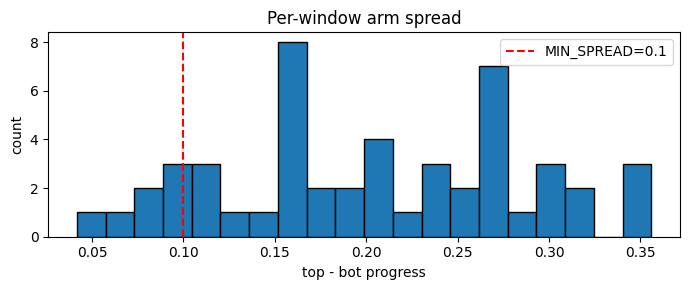

In [ ]:
import h5py, json
from tqdm import tqdm

OUT_DIR         = Path("/home/mim-server/datasets/pushT/fdpo-pairs-stageA")
# N_WINDOWS       = 50          # Day-1 smoke. Bump up after the train cycle passes.
N_WINDOWS       = len(demo_ds)          # Day-1 smoke. Bump up after the train cycle passes.
PAIRS_PER_SHARD = 64
MIN_SPREAD      = 0.10        # drop pairs with top-bot progress gap below this — they're noise

OUT_DIR.mkdir(parents=True, exist_ok=True)

def to_uint8_thwc(imgs_chw_f):
    arr = imgs_chw_f.clamp(0, 1).permute(0, 2, 3, 1).to(torch.float32).cpu().numpy()
    return (arr * 255.0).astype(np.uint8)

def write_shard(shard_path, pairs):
    n = len(pairs)
    T, H, W, C = pairs[0][0].shape
    n_act = pairs[0][1].shape[-1]
    comp = {'compression': 'gzip', 'compression_opts': 4}
    with h5py.File(shard_path, 'w') as f:
        f.create_dataset('pos_images',      data=np.stack([p[0] for p in pairs]),
                         chunks=(1, min(T, 8), H, W, C), **comp)
        f.create_dataset('pos_actions',     data=np.stack([p[1] for p in pairs]),
                         chunks=(1, min(T, 8), n_act), **comp)
        f.create_dataset('neg_images',      data=np.stack([p[2] for p in pairs]),
                         chunks=(1, min(T, 8), H, W, C), **comp)
        f.create_dataset('neg_actions',     data=np.stack([p[3] for p in pairs]),
                         chunks=(1, min(T, 8), n_act), **comp)
        f.create_dataset('episode_lengths', data=np.full((n,), T, dtype=np.int32))
        f.attrs['num_pairs'] = n

n_pairs = min(N_WINDOWS, len(demo_ds))
shard_idx, buf, spreads, kept = 0, [], [], 0

for win_idx in tqdm(range(n_pairs), desc='Stage A pairs'):
    torch.manual_seed(SEED + win_idx)   # reproducible per-window K-arm noise
    sample = demo_ds[win_idx]
    demo_imgs = sample['image'].clamp(0, 1).float()[:CTX_FRAMES+HORIZON].to(DEVICE)
    demo_acts = sample['action'][:CTX_FRAMES+HORIZON, :N_ACT].float().to(DEVICE)

    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        ctx_latents = tokenizer.encode(demo_imgs[:CTX_FRAMES].unsqueeze(0)).expand(K_ARMS, -1, -1, -1).contiguous()
        ctx_actions = demo_acts[:CTX_FRAMES].unsqueeze(0).expand(K_ARMS, -1, -1).contiguous()
        pred_latents, pred_actions = progressive_rolling_sampler(
            denoiser, init_latents=ctx_latents, init_actions=ctx_actions,
            total_pred_steps=HORIZON, window_size=WINDOW_SIZE, context_size=CTX_FRAMES,
        )
        pred_imgs = tokenizer.decode(pred_latents).clamp(0, 1)

    ctx_imgs_K = demo_imgs[:CTX_FRAMES].unsqueeze(0).expand(K_ARMS, -1, -1, -1, -1).cpu()
    arms_full  = torch.cat([ctx_imgs_K, pred_imgs.cpu()], dim=1).float()
    out_K = rm.predict(arms_full, [TASK_PROMPT] * K_ARMS)
    final_K = out_K.progress[:, -1].cpu().numpy()
    spread = float(final_K.max() - final_K.min())
    spreads.append(spread)
    if spread < MIN_SPREAD:
        continue

    top_i = int(np.argmax(final_K))
    bot_i = int(np.argmin(final_K))
    pos_imgs = to_uint8_thwc(arms_full[top_i])
    neg_imgs = to_uint8_thwc(arms_full[bot_i])
    pos_acts = torch.cat([demo_acts[:CTX_FRAMES].cpu(), pred_actions[top_i].cpu()], dim=0).numpy().astype(np.float32)
    neg_acts = torch.cat([demo_acts[:CTX_FRAMES].cpu(), pred_actions[bot_i].cpu()], dim=0).numpy().astype(np.float32)
    buf.append((pos_imgs, pos_acts, neg_imgs, neg_acts))
    kept += 1

    if len(buf) >= PAIRS_PER_SHARD:
        write_shard(OUT_DIR / f"shard_{shard_idx:04d}.h5", buf)
        shard_idx += 1
        buf = []

if buf:
    write_shard(OUT_DIR / f"shard_{shard_idx:04d}.h5", buf)
    shard_idx += 1

with open(OUT_DIR / 'metadata.json', 'w') as f:
    json.dump({
        'schema': 'fdpo_pairs_v1', 'generation_method': 'stageA_sibling_pairs',
        'ctx_frames': CTX_FRAMES, 'horizon_frames': HORIZON,
        'k_arms': K_ARMS, 'min_spread': MIN_SPREAD,
        'task_prompt': TASK_PROMPT,
        'total_pairs': kept,
        'src_data_dir': DEMO_DATA_DIR,
        'ckpt_dir': CKPT_DIR, 'ckpt_file': CKPT_FILE,
        'tokenizer_ckpt': TOKENIZER_CKPT,
        'sampler': 'progressive_rolling',
        'window_size': WINDOW_SIZE,
    }, f, indent=2, default=str)

spreads = np.array(spreads)
print(f"\n=== Stage A generation done ===")
print(f"  shards written:           {shard_idx}  ({OUT_DIR})")
print(f"  pairs kept:               {kept} / {len(spreads)}")
print(f"  spread (top - bot):       min={spreads.min():.2f}  med={np.median(spreads):.2f}  max={spreads.max():.2f}")
print(f"  dropped (spread < {MIN_SPREAD}):  {(spreads < MIN_SPREAD).sum()}")

# Quick histogram for sanity.
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(spreads, bins=20, edgecolor='black')
ax.axvline(MIN_SPREAD, color='red', linestyle='--', label=f'MIN_SPREAD={MIN_SPREAD}')
ax.set_xlabel('top - bot progress'); ax.set_ylabel('count'); ax.legend(); ax.set_title('Per-window arm spread')
plt.tight_layout(); plt.show()

## Train Stage A LoRA + eval

Drop-in to the existing FDPO trainer — just point `fdpo.pairs_dir` at the Stage A shards:

```bash
torchrun --standalone --nproc_per_node=1 scripts/train_align_fdpo.py \
    fdpo.pairs_dir=/home/mim-server/datasets/pushT/fdpo-pairs-stageA \
    fdpo.play_data_dir=/home/mim-server/datasets/pushT/sharded \
    fdpo.dpo_streams=obs \
    fdpo.anchor_weight=0.5 fdpo.wm_anchor_weight=1.0 fdpo.beta=0.1 \
    train.num_epochs=5 train.batch_per_gpu=2 train.accum_grad_steps=2 \
    train.num_workers=4 train.lr=1e-4 \
    fdpo.play_batch_per_gpu=1 \
    lora.r=8 lora.lora_alpha=16 \
    output_dir=checkpoints/align/stageA-pushT \
    wandb.enable=false print_every=20 save_every=200 \
    2>&1 | tee tmp/fdpo_train_stageA.log
```

Eval (three scalars + viz):
```bash
python scripts/eval_fdpo_offline.py    --aligned_adapter checkpoints/align/stageA-pushT
python scripts/fdpo_vis/viz_aligned_rollouts.py --aligned_ckpt checkpoints/align/stageA-pushT/final_merged.pt
```

**Day-3 gate** (from the 2-week plan):
1. Demo policy loss decreases vs. ref.
2. Play policy + play WM loss stay within ±2× ref (mode retention).
3. Viz: aligned rollouts visibly complete pushT goal more than ref.

All three pass → continue to ablations. Otherwise: ONE iteration (tighten quantile, raise K, lower lr), then decide.

## Visualize Stage A pairs

For $N$ randomly sampled pairs from `/home/mim-server/datasets/pushT/fdpo-pairs-stageA`:

- **Side-by-side video** — pos (high-progress arm) on the left, neg (low-progress arm) on the right. Both start from the identical demo context (the first `ctx_frames` frame).
- **Robometer progress curves** — pos in green, neg in red, with a dotted line marking the context/horizon boundary.
- **Action curves** — pos and neg overlaid, same color coding.

Re-runs of the cell re-sample `N_VIZ` random pair indices.


In [ ]:
# Visualize randomly sampled Stage A pairs.
from dreamerv4uwm.datasets import PreferencePairDataset
import mediapy

stageA_ds = PreferencePairDataset(
    data_dir='/home/mim-server/datasets/pushT/fdpo-pairs-stageA',
    split='train', train_fraction=1.0, split_seed=42, shuffle_pairs=False,
)
print(f"loaded {len(stageA_ds)} Stage A pairs   ctx={stageA_ds.ctx_frames}  horizon={stageA_ds.horizon_frames}")

def _side_by_side_video(pos_img_t3hw, neg_img_t3hw, border=4):
    """pos/neg: (T, 3, H, W) float in [0,1]. Returns (T, H, 2W+border, 3) uint8."""
    T, _, H, W = pos_img_t3hw.shape
    sep = torch.zeros(T, 3, H, border)
    combined = torch.cat([pos_img_t3hw, sep, neg_img_t3hw], dim=-1)
    return (combined.clamp(0, 1).permute(0, 2, 3, 1) * 255).to(torch.uint8).numpy()

N_VIZ = 4
torch.manual_seed(int(torch.empty((), dtype=torch.int64).random_().item()))  # fresh sample each run
viz_indices = torch.randperm(len(stageA_ds))[:N_VIZ].tolist()
print(f"sampling pairs: {viz_indices}")

for idx in viz_indices:
    s = stageA_ds[idx]
    pos_img = s['pos_image'].clamp(0, 1).float()   # (T, 3, H, W)
    neg_img = s['neg_image'].clamp(0, 1).float()
    pos_act = s['pos_action']                       # (T, n_act)
    neg_act = s['neg_action']

    pos_score = rm.predict(pos_img[None], [TASK_PROMPT]).progress[0].cpu().numpy()
    neg_score = rm.predict(neg_img[None], [TASK_PROMPT]).progress[0].cpu().numpy()

    print(f"\n=== pair {idx}   pos final={pos_score[-1]:.3f}   neg final={neg_score[-1]:.3f}   "
          f"spread={pos_score[-1] - neg_score[-1]:+.3f} ===")

    video = _side_by_side_video(pos_img, neg_img)
    mediapy.show_video(video, fps=5)

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    axes[0].plot(pos_score, label='pos', color='green', lw=2)
    axes[0].plot(neg_score, label='neg', color='red',   lw=2)
    axes[0].axvline(stageA_ds.ctx_frames - 0.5, color='k', linestyle=':', alpha=0.4, label='ctx|hor')
    axes[0].set_xlabel('frame'); axes[0].set_ylabel('progress')
    axes[0].set_ylim(-0.05, 1.05); axes[0].grid(alpha=0.3); axes[0].legend()
    axes[0].set_title('Robometer progress')

    for d in range(pos_act.shape[-1]):
        axes[1].plot(pos_act[:, d].numpy(), color='green', alpha=0.7, lw=1.2)
        axes[1].plot(neg_act[:, d].numpy(), color='red',   alpha=0.7, lw=1.2)
    axes[1].axvline(stageA_ds.ctx_frames - 0.5, color='k', linestyle=':', alpha=0.4)
    axes[1].set_xlabel('frame'); axes[1].set_ylabel('action value')
    axes[1].set_title('Actions (green=pos, red=neg, all dims overlaid)')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


## Visualize aligned vs ref rollouts (3-row comparison)

Load the LoRA-tuned (aligned) model alongside the frozen reference and, for held-out demo and play windows, generate side-by-side 3-row videos:

- **Row 1 (gt)** — ground-truth continuation
- **Row 2 (ref)** — frozen reference rollout from the same context
- **Row 3 (aligned)** — LoRA-tuned rollout from the same context

This is the disambiguator between three regimes that the offline scalar can't distinguish:

- **Specialization**: aligned looks demo-like even on play context — valid task motion biased toward expert behavior. High MSE vs. gt is fine.
- **Pathology**: aligned outputs are noise / blob / off-manifold. The LoRA has broken generative capability.
- **Multi-modality**: aligned looks like a different but task-valid trajectory than gt. Also fine.

Per memory: **the play-source viz is the load-bearing retention test.** v0a showed specialization on demo source and pathology on play source — only viz separates them.

Run order: setup → demo viz → play viz.

In [ ]:
# === Setup: load aligned model from adapter; define rollout + 3-row video helpers ===
import json
from pathlib import Path
from omegaconf import OmegaConf
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict

from dreamerv4uwm.datasets import PreferencePairDataset, ShardedHDF5Dataset

# --- knobs ---
ADAPTER_PATH  = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/align/v1-stride5-ctx1-h16-temporal/adapter_1167.pt'
PAIRS_DIR     = '/home/mim-server/datasets/pushT/fdpo-pairs-v1'
PLAY_DIR      = '/home/mim-server/datasets/pushT/sharded'
PROGRESSIVE_F = 16          # progressive sampler staircase depth
FPS_VIZ       = 5
N_DEMO        = 4
N_PLAY        = 4

# --- resolve ctx/horizon from the trained pairs metadata so viz matches training ---
_meta = json.loads((Path(PAIRS_DIR) / 'metadata.json').read_text())
CTX_FRAMES_VIZ = int(_meta.get('ctx_frames', 1))
HORIZON_VIZ    = int(_meta.get('horizon_frames', 16))
MAX_SEQ_VIZ    = CTX_FRAMES_VIZ + HORIZON_VIZ
print(f"viz ctx={CTX_FRAMES_VIZ}  horizon={HORIZON_VIZ}  max_seq={MAX_SEQ_VIZ}")

# --- reload models at the right max_seq (cell 4 may have loaded shorter) ---
_cfg = OmegaConf.load(Path(CKPT_DIR) / 'config.yaml')
_cfg.dynamics_ckpt  = str(Path(CKPT_DIR) / CKPT_FILE)
_cfg.tokenizer_ckpt = TOKENIZER_CKPT
if 'latent_attends_action' in _cfg.denoiser:
    del _cfg.denoiser['latent_attends_action']

tokenizer_viz = load_tokenizer(_cfg, DEVICE, max_num_forward_steps=MAX_SEQ_VIZ).eval()
for p in tokenizer_viz.parameters(): p.requires_grad_(False)
ref = load_denoiser(_cfg, DEVICE, max_num_forward_steps=MAX_SEQ_VIZ).eval()
for p in ref.parameters(): p.requires_grad_(False)

# --- aligned = ref + LoRA adapter from training checkpoint ---
_adapter_path  = Path(ADAPTER_PATH)
_train_cfg     = OmegaConf.load(_adapter_path.parent / 'config.yaml')
_lora          = _train_cfg.lora
_target        = (list(_lora.target_modules)
                  if hasattr(_lora.target_modules, '__iter__') and not isinstance(_lora.target_modules, str)
                  else _lora.target_modules)
_modules_save  = list(_lora.modules_to_save) if _lora.get('modules_to_save', None) is not None else None
_lora_cfg = LoraConfig(
    r=int(_lora.r), lora_alpha=int(_lora.lora_alpha),
    lora_dropout=float(_lora.lora_dropout), bias=str(_lora.bias),
    target_modules=_target, modules_to_save=_modules_save,
)
aligned = load_denoiser(_cfg, DEVICE, max_num_forward_steps=MAX_SEQ_VIZ)
aligned = get_peft_model(aligned, _lora_cfg)
_ckpt = torch.load(_adapter_path, map_location=DEVICE, weights_only=False)
set_peft_model_state_dict(aligned, _ckpt['adapter'])
aligned = aligned.eval()
for p in aligned.parameters(): p.requires_grad_(False)
print(f"loaded aligned LoRA from {_adapter_path}")


@torch.no_grad()
def _rollout(model, ctx_imgs_chw, ctx_acts):
    """(T_ctx, 3, H, W) ctx imgs + (T_ctx, n_act) ctx acts → (horizon, 3, H, W) decoded imgs + (horizon, n_act) acts."""
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_ctx = tokenizer_viz.encode(ctx_imgs_chw.unsqueeze(0))
        pred_lat, pred_act = progressive_rolling_sampler(
            model, z_ctx, ctx_acts.unsqueeze(0).to(z_ctx.dtype),
            total_pred_steps=HORIZON_VIZ, window_size=PROGRESSIVE_F,
            context_size=CTX_FRAMES_VIZ,
        )
        pred_imgs = tokenizer_viz.decode(pred_lat)[0].clamp(0, 1)
    return pred_imgs.to(torch.float32), pred_act[0].to(torch.float32)


def _build_3row_video(gt_chw, ref_chw, aligned_chw, separator=3):
    """Stack three rows vertically into one (T, 3H+2sep, W, 3) uint8 array for inline display."""
    def _u8(imgs_chw):
        return (imgs_chw.clamp(0,1).permute(0,2,3,1).cpu().numpy() * 255).astype(np.uint8)
    g, r, a = _u8(gt_chw), _u8(ref_chw), _u8(aligned_chw)
    T, H, W, C = g.shape
    sep = np.zeros((T, separator, W, C), dtype=np.uint8)
    return np.concatenate([g, sep, r, sep, a], axis=1)


def _viz_window(tag, idx, gt_chw_full, gt_actions):
    """Run ref + aligned rollouts from the same demo context; show 3-row video + action plot."""
    ctx_imgs = gt_chw_full[:CTX_FRAMES_VIZ].to(DEVICE).to(torch.float32)
    ctx_acts = gt_actions[:CTX_FRAMES_VIZ, :N_ACT].to(DEVICE).to(torch.float32)

    ref_hor_imgs, ref_hor_acts = _rollout(ref, ctx_imgs, ctx_acts)
    ali_hor_imgs, ali_hor_acts = _rollout(aligned, ctx_imgs, ctx_acts)

    gt_full  = gt_chw_full[:MAX_SEQ_VIZ].to(torch.float32)
    ref_full = torch.cat([ctx_imgs.cpu(), ref_hor_imgs.cpu()], dim=0)
    ali_full = torch.cat([ctx_imgs.cpu(), ali_hor_imgs.cpu()], dim=0)

    print(f"\n=== {tag} window {idx}  (top: gt   mid: ref   bot: aligned) ===")
    mediapy.show_video(_build_3row_video(gt_full, ref_full, ali_full), fps=FPS_VIZ)

    # Horizon-only action comparison
    fig, axes = plt.subplots(N_ACT, 1, figsize=(10, 1.6 * N_ACT), sharex=True)
    if N_ACT == 1:
        axes = [axes]
    gt_h  = gt_actions[CTX_FRAMES_VIZ:MAX_SEQ_VIZ, :N_ACT].numpy()
    ref_h = ref_hor_acts.cpu().numpy()
    ali_h = ali_hor_acts.cpu().numpy()
    t = np.arange(HORIZON_VIZ)
    for d, ax in enumerate(axes):
        ax.plot(t, gt_h[:, d],  '-',  color='C0', lw=1.6, label='gt')
        ax.plot(t, ref_h[:, d], '--', color='C1', lw=1.4, label='ref')
        ax.plot(t, ali_h[:, d], ':',  color='C2', lw=1.8, label='aligned')
        ax.set_ylabel(f'a[{d}]'); ax.grid(alpha=0.3)
    axes[-1].set_xlabel('horizon frame')
    axes[0].legend(loc='upper right', fontsize=8)
    fig.suptitle(f'{tag} window {idx} — horizon actions', fontsize=10)
    plt.tight_layout(); plt.show()

print('setup complete: ref, aligned, tokenizer_viz, _rollout, _viz_window')


In [ ]:
# === Demo-source viz: held-out pairs (positives only) ===
demo_test_ds = PreferencePairDataset(
    data_dir=PAIRS_DIR, split='test',
    train_fraction=0.9, split_seed=42, shuffle_pairs=False,
)
print(f"held-out demo pairs: {len(demo_test_ds)}")

torch.manual_seed(0)
for i in range(min(N_DEMO, len(demo_test_ds))):
    s = demo_test_ds[i]
    _viz_window('demo', i, s['pos_image'], s['pos_action'])


In [ ]:
# === Play-source viz: held-out play windows.
# This is the load-bearing retention test — v0a showed pathology specifically on play context.
play_test_ds = ShardedHDF5Dataset(
    data_dir=PLAY_DIR, window_size=MAX_SEQ_VIZ,
    stride=64, split='test', train_fraction=0.9, split_seed=42,
    shuffle_windows=False,
)
print(f"held-out play windows: {len(play_test_ds)}")

torch.manual_seed(0)
for i in range(min(N_PLAY, len(play_test_ds))):
    s = play_test_ds[i]
    _viz_window('play', i, s['image'], s['action'])


## Long-horizon rollout stress test (play source)

Roll out ref + aligned for **many more iterations than the trained horizon** to see whether learned behavior maintains coherence past the training distribution. Two questions:

- **Does the aligned model stay on-manifold past the 16-frame trained horizon?** If pathology shows up only after extrapolation, the LoRA over-specialized to short windows.
- **Does the alignment effect compound or decay over longer rollouts?** A red dashed vertical line in the action plot marks where the trained horizon ends — anything past that is extrapolation territory.

The progressive rolling sampler is bounded per-step at `C+F = 17` frames regardless of total rollout length, so the denoiser never sees a sequence longer than what it was trained on. Only the autoregressive loop runs longer.

Knob: `LONG_HORIZON` (default 64 = 4× trained horizon). Bump cautiously — wall time scales linearly in horizon × (ref + aligned).

In [ ]:
# === Long-horizon play-source viz ===
LONG_HORIZON = 64
LONG_MAX_SEQ = CTX_FRAMES_VIZ + LONG_HORIZON
N_LONG       = 3

play_test_ds_long = ShardedHDF5Dataset(
    data_dir=PLAY_DIR, window_size=LONG_MAX_SEQ,
    stride=LONG_MAX_SEQ, split='test', train_fraction=0.9, split_seed=42,
    shuffle_windows=False,
)
print(f"long-horizon play windows: {len(play_test_ds_long)}  (window={LONG_MAX_SEQ}, stride={LONG_MAX_SEQ})")


@torch.no_grad()
def _rollout_n(model, ctx_imgs_chw, ctx_acts, horizon):
    """Like _rollout but with a configurable horizon — for stress-testing past trained length."""
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_ctx = tokenizer_viz.encode(ctx_imgs_chw.unsqueeze(0))
        pred_lat, pred_act = progressive_rolling_sampler(
            model, z_ctx, ctx_acts.unsqueeze(0).to(z_ctx.dtype),
            total_pred_steps=horizon, window_size=PROGRESSIVE_F,
            context_size=CTX_FRAMES_VIZ,
        )
        pred_imgs = tokenizer_viz.decode(pred_lat)[0].clamp(0, 1)
    return pred_imgs.to(torch.float32), pred_act[0].to(torch.float32)


torch.manual_seed(0)
for i in range(min(N_LONG, len(play_test_ds_long))):
    s = play_test_ds_long[i]
    gt_full    = s['image']                                  # (LONG_MAX_SEQ, 3, H, W)
    gt_actions = s['action']                                 # (LONG_MAX_SEQ, n_act_full)

    ctx_imgs = gt_full[:CTX_FRAMES_VIZ].to(DEVICE).to(torch.float32)
    ctx_acts = gt_actions[:CTX_FRAMES_VIZ, :N_ACT].to(DEVICE).to(torch.float32)

    ref_hor_imgs, ref_hor_acts = _rollout_n(ref,     ctx_imgs, ctx_acts, LONG_HORIZON)
    ali_hor_imgs, ali_hor_acts = _rollout_n(aligned, ctx_imgs, ctx_acts, LONG_HORIZON)

    gt_view  = gt_full[:LONG_MAX_SEQ].to(torch.float32)
    ref_view = torch.cat([ctx_imgs.cpu(), ref_hor_imgs.cpu()], dim=0)
    ali_view = torch.cat([ctx_imgs.cpu(), ali_hor_imgs.cpu()], dim=0)

    print(f"\n=== long play window {i}  (horizon={LONG_HORIZON})  top: gt  mid: ref  bot: aligned ===")
    mediapy.show_video(_build_3row_video(gt_view, ref_view, ali_view), fps=FPS_VIZ)

    fig, axes = plt.subplots(N_ACT, 1, figsize=(12, 1.6 * N_ACT), sharex=True)
    if N_ACT == 1:
        axes = [axes]
    gt_h  = gt_actions[CTX_FRAMES_VIZ:LONG_MAX_SEQ, :N_ACT].numpy()
    ref_h = ref_hor_acts.cpu().numpy()
    ali_h = ali_hor_acts.cpu().numpy()
    t = np.arange(LONG_HORIZON)
    for d, ax in enumerate(axes):
        ax.plot(t, gt_h[:, d],  '-',  color='C0', lw=1.4, label='gt')
        ax.plot(t, ref_h[:, d], '--', color='C1', lw=1.2, label='ref')
        ax.plot(t, ali_h[:, d], ':',  color='C2', lw=1.6, label='aligned')
        ax.axvline(HORIZON_VIZ - 0.5, color='red', linestyle='--', alpha=0.6,
                   label='trained horizon' if d == 0 else None)
        ax.set_ylabel(f'a[{d}]'); ax.grid(alpha=0.3)
    axes[-1].set_xlabel('horizon frame')
    axes[0].legend(loc='upper right', fontsize=8)
    fig.suptitle(f'long play window {i} — extended horizon ({LONG_HORIZON} frames)', fontsize=10)
    plt.tight_layout(); plt.show()
